In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from joblib import dump

---
## Load Dataset

In [131]:
df = pd.read_csv('../data/laptop_processed.csv')

In [132]:
df.head()

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
0,Apple,MacBook Pro,Ultrabook,13.3,macOS,1339.69,Intel,Core i5,2.3,Intel,...,1.0,0.0,1.0,226.983005,8.0,1.37,128.0,0.0,0.0,0.0
1,Apple,Macbook Air,Ultrabook,13.3,macOS,898.94,Intel,Core i5,1.8,Intel,...,0.0,0.0,0.0,127.677940,8.0,1.34,0.0,0.0,128.0,0.0
2,HP,250 G6,Notebook,15.6,No OS,575.00,Intel,Core i5 7200U,2.5,Intel,...,0.0,0.0,0.0,141.211998,8.0,1.86,256.0,0.0,0.0,0.0
3,Apple,MacBook Pro,Ultrabook,15.4,macOS,2537.45,Intel,Core i7,2.7,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,512.0,0.0,0.0,0.0
4,Apple,MacBook Pro,Ultrabook,13.3,macOS,1803.60,Intel,Core i5,3.1,Intel,...,1.0,0.0,1.0,226.983005,8.0,1.37,256.0,0.0,0.0,0.0


---
## Preprocessing

In [133]:
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [135]:
string_columns = X.select_dtypes(include=['object']).columns

In [136]:
string_columns

Index(['Company', 'Product', 'TypeName', 'OpSys', 'Cpu_brand', 'Cpu_model',
       'Gpu_brand', 'Gpu_series'],
      dtype='object')

In [137]:
numeric_columns = X.select_dtypes(exclude=['object']).columns

In [138]:
numeric_columns

Index(['Inches', 'Cpu_clock_rate_(GHz)', 'Ips_panel', 'Touchscreen',
       'Retina_display', 'PPI', 'Ram_(GB)', 'Weight_(kg)', 'Memory_SSD_(GB)',
       'Memory_HDD_(GB)', 'Memory_Flash_Storage_(GB)', 'Memory_Hybrid_(GB)'],
      dtype='object')

**Preprocessor for Linear model**

In [139]:
preprocessor = ColumnTransformer([
    ('string_columns', OneHotEncoder(handle_unknown='ignore'), string_columns),
    ('numeric_columns', StandardScaler(), numeric_columns)
])

**Preprocessor for Tree based model**

In [140]:
preprocessor_tree = ColumnTransformer([
    ('string_columns', OneHotEncoder(handle_unknown='ignore'), string_columns),
    ('numeric_columns', 'passthrough', numeric_columns)
])

**Since tree based models do not require feature scaling, we create a separate preprocessor for tree based models that does not perform feature scaling**

---
## Training base models

In [141]:
def score_calc(cv):
    result = dict()
    
    cv_r2 = cv['test_r2']
    cv_mae = -cv['test_mae']
    cv_rmse = -cv['test_rmse']
    
    result['r2_mean'] = cv_r2.mean()
    result['r2_std'] = cv_r2.std()
    
    result['mae_mean'] = cv_mae.mean()
    result['mae_std'] = cv_mae.std()
    
    result['rmse_mean'] = cv_rmse.mean()
    result['rmse_std'] = cv_rmse.std()
    
    
    return result

In [142]:
def base_model_training(x_data, y_data, preprocessor_step, base_model):
    errors_dict = {
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    }
    
    pipe = Pipeline(steps=[
    ('preprocessor', preprocessor_step),
    ('model', base_model)
    ])
    
    wrapped_model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=101)
    
    cv = cross_validate(
        estimator=wrapped_model,
        X=x_data,
        y=y_data,
        scoring=errors_dict,
        cv=kf,
    )
    
    cv_score = score_calc(cv)
    
    return cv_score 

In [143]:
models = {
    'linear_regression': LinearRegression(),
    'elastic_net': ElasticNet(random_state=101),
    'svr': SVR(),
    'random_forest': RandomForestRegressor(random_state=101),
    'gradient_boosting': GradientBoostingRegressor(random_state=101),
    'adaboost': AdaBoostRegressor(random_state=101)
}

In [144]:
model_errors = dict()

for name, model in models.items():
    
    
    if name in ['random_forest', 'gradient_boosting', 'adaboost']:
        preprocessor_step = preprocessor_tree
    else:
        preprocessor_step = preprocessor
        
    result = base_model_training(X_train, y_train, preprocessor_step, model)
    
    model_errors[name] = {
        'r2_mean': result['r2_mean'],
        'r2_std': result['r2_std'],
        'mae_mean': result['mae_mean'],
        'mae_std': result['mae_std'],
        'rmse_mean': result['rmse_mean'],
        'rmse_std': result['rmse_std']
    }

In [145]:
errors_df = pd.DataFrame(data=model_errors.values(), index=model_errors.keys())

In [154]:
errors_df

,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
linear_regression,0.762108,0.032931,208.365956,17.254648,333.647477,47.904735
elastic_net,-0.080162,0.051300,518.684323,28.410529,708.996782,59.527361
svr,0.788884,0.065720,184.913133,18.607539,313.379496,72.958353
random_forest,0.807105,0.028688,186.302390,8.132406,300.259276,44.505296
gradient_boosting,0.816695,0.026011,192.398795,15.430144,292.570913,40.738999
adaboost,0.711149,0.043093,249.928234,20.377587,367.007068,50.465009


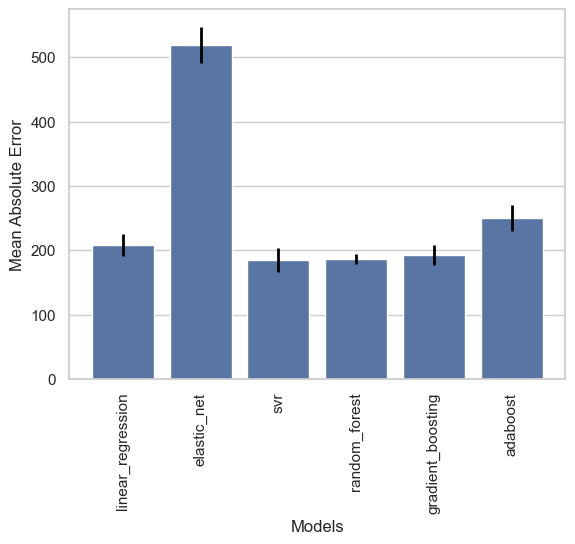

In [156]:
sns.barplot(data=errors_df, x=errors_df.index, y='mae_mean')
plt.errorbar(x=np.arange(len(errors_df)), y=errors_df['mae_mean'], yerr=errors_df['mae_std'], fmt='none', c='black', lw=2)
plt.xlabel("Models")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=90);

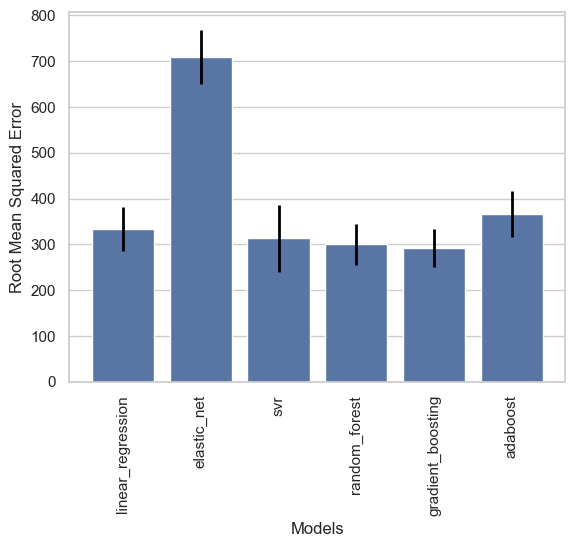

In [159]:
sns.barplot(data=errors_df, x=errors_df.index, y='rmse_mean')
plt.errorbar(x=np.arange(len(errors_df)), y=errors_df['rmse_mean'], yerr=errors_df['rmse_std'], fmt='none', c='black', lw=2)
plt.xlabel("Models")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=90);

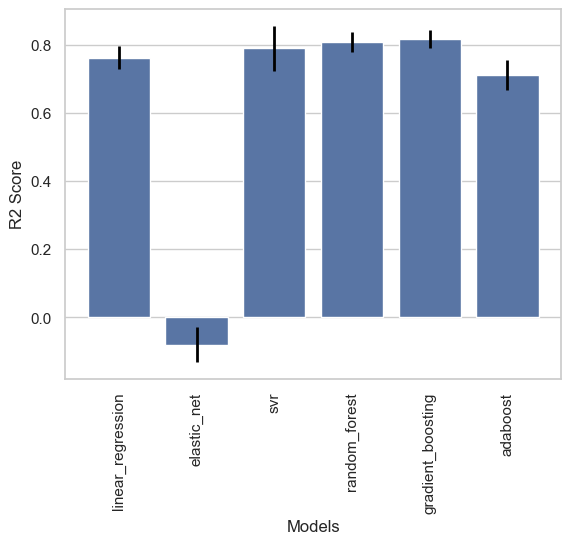

In [158]:
sns.barplot(data=errors_df, x=errors_df.index, y='r2_mean')
plt.errorbar(x=np.arange(len(errors_df)), y=errors_df['r2_mean'], yerr=errors_df['r2_std'], fmt='none', c='black', lw=2)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=90);

**According to the error values and r2 score, two models, random forest and gradient boosting, are selected for tuning.**

---
## Tune Models

In [234]:
def tune_model_training(x_data, y_data, preprocessor_step, tune_model):
    tune_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_step),
        (model_name, tune_model),
    ])
    
    tune_wrapped_model = TransformedTargetRegressor(
        regressor=tune_pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    random_search = RandomizedSearchCV(
        estimator=tune_wrapped_model,
        param_distributions=param_search,
        n_iter=30,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=101,
    )
    
    random_search.fit(x_data, y_data)
    
    return random_search

In [235]:
params_search = {
    'random_forest': {
        'regressor__random_forest__n_estimators': [100, 200, 300, 400],
        'regressor__random_forest__criterion': ["squared_error", "absolute_error", "friedman_mse", "poisson"],
        'regressor__random_forest__max_depth': [None, 10, 20, 30],
        'regressor__random_forest__min_samples_split': [2, 5, 10],
        'regressor__random_forest__max_features': ["sqrt", "log2"],
        'regressor__random_forest__bootstrap': [True, False],
        'regressor__random_forest__oob_score': [True, False],
    },
    'gradient_boosting': {
        'regressor__gradient_boosting__n_estimators': [100, 200, 300, 400],
        'regressor__gradient_boosting__learning_rate': np.logspace(-2, 0, num=5, base=10),
        'regressor__gradient_boosting__criterion': ['friedman_mse', 'squared_error'],
        'regressor__gradient_boosting__max_depth': [None, 10, 20, 30],
        'regressor__gradient_boosting__min_samples_split': [2, 5, 10],
        'regressor__gradient_boosting__max_features': ["sqrt", "log2"],
    }
}

In [236]:
tune_models = dict()
tune_scores = dict()

for model_name, param_search in params_search.items():
    tune_model = tune_model_training(X_train, y_train, preprocessor_tree, models[model_name])
    
    tune_models[model_name] = tune_model
    tune_scores[model_name] = -tune_model.best_score_

D:\programming\codes\ml\venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "D:\programming\codes\ml\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\programming\codes\ml\venv\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\programming\codes\ml\venv\Lib\site-packages\sklearn\compose\_target.py", line 293, in fit
    s

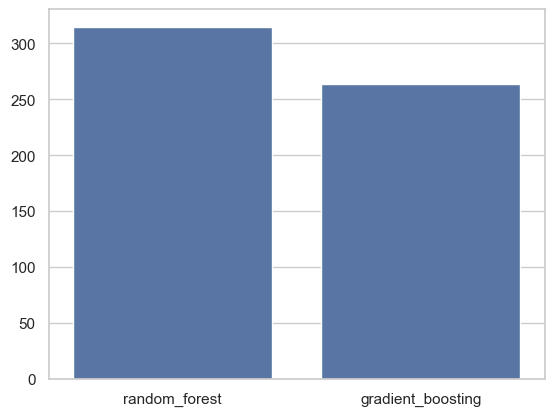

In [237]:
sns.barplot(data=tune_scores);

**In the tune step, the RMSE error value of the GradientBoostingRegressor model is less than the RandomForestRegressor model, so we choose the GradientBoostingRegressor model as the final model for this project.**

---
## Final Evaluation

In [238]:
final_model = tune_models['gradient_boosting']

In [239]:
final_model.best_params_

{'regressor__gradient_boosting__n_estimators': 400,
 'regressor__gradient_boosting__min_samples_split': 5,
 'regressor__gradient_boosting__max_features': 'sqrt',
 'regressor__gradient_boosting__max_depth': 10,
 'regressor__gradient_boosting__learning_rate': np.float64(0.03162277660168379),
 'regressor__gradient_boosting__criterion': 'friedman_mse'}

In [240]:
predict = final_model.predict(X_test)

In [241]:
r2 = r2_score(y_test, predict)

In [242]:
r2

0.8838272134295778

In [243]:
mae = mean_absolute_error(y_test, predict)

In [244]:
mae

148.28162592304494

In [245]:
rmse = np.sqrt(mean_squared_error(y_test, predict))

In [246]:
rmse

np.float64(257.17032862467636)

In [247]:
residual = y_test - predict

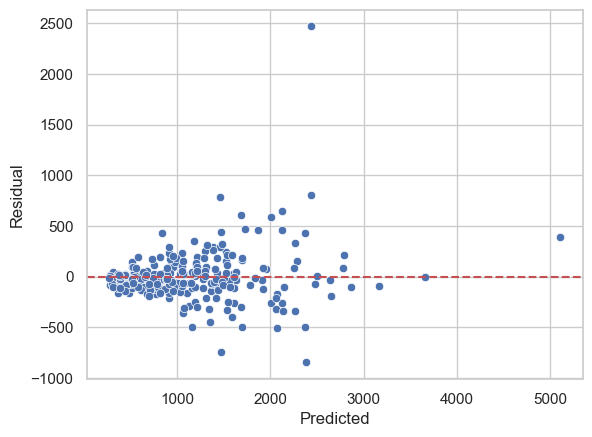

In [248]:
sns.scatterplot(x=predict, y=residual)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual');

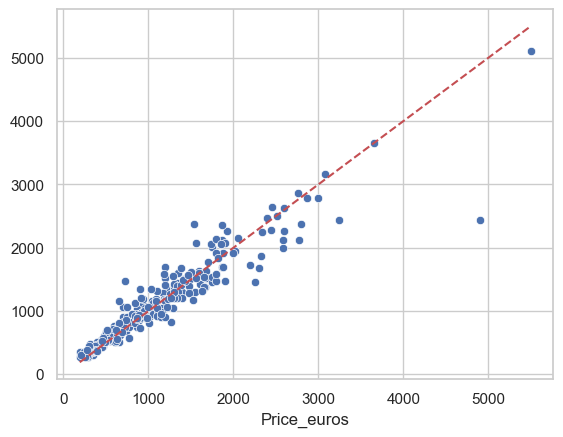

In [249]:
sns.scatterplot(x=y_test, y=predict)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
);

## Feature Importances

In [250]:
feature_importances = final_model.best_estimator_.regressor_.named_steps['gradient_boosting'].feature_importances_

In [251]:
feature_name = final_model.best_estimator_.regressor_.named_steps['preprocessor'].get_feature_names_out()

In [252]:
feature_name = np.vectorize(lambda x: x.split('__')[1])(feature_name)

In [253]:
feature_importances_df = pd.DataFrame(
    data=feature_importances,
    index=feature_name,
    columns=['Importance']
).sort_values(by='Importance', ascending=False).head(15)

In [254]:
feature_importances_df

,Importance
Ram_(GB),0.111973
Memory_SSD_(GB),0.096271
Cpu_clock_rate_(GHz),0.094503
PPI,0.069752
TypeName_Notebook,0.046648
Weight_(kg),0.044585
Inches,0.035237
Gpu_series_HD Graphics 400,0.023706
Cpu_model_Core i7 7700HQ,0.021075
Ips_panel,0.020000


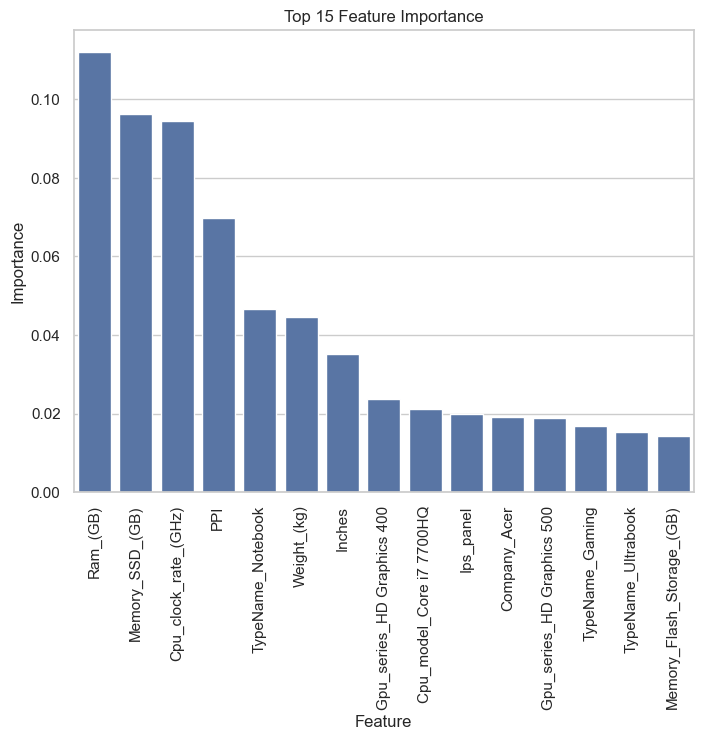

In [255]:
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importances_df.index, y=feature_importances_df.Importance)
plt.xlabel('Feature')
plt.title('Top 15 Feature Importance')
plt.xticks(rotation=90);

## Save Final Model

In [ ]:
dump(final_model, '../final_model/final_model.pkl')